In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (train_test_split, RepeatedStratifiedKFold,
                                     StratifiedKFold, cross_validate, cross_val_predict)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve
from sklearn.metrics import (roc_auc_score, average_precision_score, roc_curve,
                             confusion_matrix, recall_score, precision_score,
                             f1_score, brier_score_loss)
from xgboost import XGBClassifier

RANDOM_STATE = 42
TARGET_RECALL = 0.85          # screening goal: catch >= 85% of diabetics
SELECTION_METRIC = "roc_auc"  # metric used to pick the best model

print("Libraries imported successfully")
print(f"Random state        : {RANDOM_STATE}")
print(f"Target recall       : {TARGET_RECALL:.0%}")
print(f"Selection metric    : {SELECTION_METRIC}")

Libraries imported successfully
Random state        : 42
Target recall       : 85%
Selection metric    : roc_auc


In [3]:
# Load and inspect data
# Adjust the path to match the Kaggle sidebar

import os

# 1. List every file under /kaggle/input so you can see the real path
csv_files = []
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        print(os.path.join(root, f))
        if f.lower().endswith(".csv"):
            csv_files.append(os.path.join(root, f))

# 2. Pick the CSV automatically (stops with a clear message if none or several)
if len(csv_files) == 0:
    raise FileNotFoundError("No CSV found. Click 'Add Input' in the Kaggle sidebar and attach the dataset.")
elif len(csv_files) > 1:
    print("\nMore than one CSV found. Set DATA_PATH below to the one you want.")
DATA_PATH = csv_files[0]
print(f"\nUsing file: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)

print("=" * 50)
print("DATA LOADED")
print("=" * 50)
print(f"Rows (patients)  : {df.shape[0]}")
print(f"Columns          : {df.shape[1]}")
print(f"Column names     : {list(df.columns)}")
print(f"Duplicate rows   : {df.duplicated().sum()}")

counts = df["Outcome"].value_counts()
print("\nClass distribution (Outcome):")
print(f"  Not diabetic (0): {counts[0]}  ({counts[0]/len(df):.1%})")
print(f"  Diabetic     (1): {counts[1]}  ({counts[1]/len(df):.1%})")
df.head()

/kaggle/input/datasets/mragpavank/diabetes/diabetes.csv

Using file: /kaggle/input/datasets/mragpavank/diabetes/diabetes.csv
DATA LOADED
Rows (patients)  : 768
Columns          : 9
Column names     : ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
Duplicate rows   : 0

Class distribution (Outcome):
  Not diabetic (0): 500  (65.1%)
  Diabetic     (1): 268  (34.9%)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
#clean the data
# Zeros in these columns are physiologically impossible -> treat as missing.
# Imputation happens later inside the pipeline, so there is no data leakage.
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

print("Impossible zeros found (before cleaning):")
for col in zero_as_missing:
    print(f"  {col:15s}: {(df[col] == 0).sum():4d} zeros")

df[zero_as_missing] = df[zero_as_missing].replace(0, np.nan)

print("\nMissing values after converting zeros to NaN:")
for col in zero_as_missing:
    n = df[col].isna().sum()
    print(f"  {col:15s}: {n:4d} missing ({n/len(df):.1%})")
print("\nNote: these will be filled with the training-set median inside each pipeline")

Impossible zeros found (before cleaning):
  Glucose        :    5 zeros
  BloodPressure  :   35 zeros
  SkinThickness  :  227 zeros
  Insulin        :  374 zeros
  BMI            :   11 zeros

Missing values after converting zeros to NaN:
  Glucose        :    5 missing (0.7%)
  BloodPressure  :   35 missing (4.6%)
  SkinThickness  :  227 missing (29.6%)
  Insulin        :  374 missing (48.7%)
  BMI            :   11 missing (1.4%)

Note: these will be filled with the training-set median inside each pipeline


In [5]:
#Feature sets and train/test split

# Model A = routine measurements only (answers the capstone question)
# Model B = routine + lab features (benchmark only)
routine = ["Pregnancies", "BloodPressure", "SkinThickness",
           "BMI", "DiabetesPedigreeFunction", "Age"]
lab = ["Glucose", "Insulin"]

print("Model A features (routine):", routine)
print("Model B features (routine + lab):", routine + lab)

# Stratified split keeps the same diabetic ratio in train and test.
# The test set is NOT touched until the final evaluation.
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["Outcome"],
                                     random_state=RANDOM_STATE)
y_train, y_test = train_df["Outcome"], test_df["Outcome"]

# Class-imbalance ratio for XGBoost
spw = (y_train == 0).sum() / (y_train == 1).sum()

print("\n" + "=" * 50)
print("TRAIN / TEST SPLIT")
print("=" * 50)
print(f"Total patients   : {len(df)}")
print(f"Training set     : {len(train_df)} patients ({len(train_df)/len(df):.0%})")
print(f"  - not diabetic : {(y_train == 0).sum()}")
print(f"  - diabetic     : {(y_train == 1).sum()}  ({y_train.mean():.1%})")
print(f"Test set         : {len(test_df)} patients ({len(test_df)/len(df):.0%})")
print(f"  - not diabetic : {(y_test == 0).sum()}")
print(f"  - diabetic     : {(y_test == 1).sum()}  ({y_test.mean():.1%})")
print(f"\nXGBoost scale_pos_weight (imbalance ratio): {spw:.2f}")

Model A features (routine): ['Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Model B features (routine + lab): ['Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Glucose', 'Insulin']

TRAIN / TEST SPLIT
Total patients   : 768
Training set     : 614 patients (80%)
  - not diabetic : 400
  - diabetic     : 214  (34.9%)
Test set         : 154 patients (20%)
  - not diabetic : 100
  - diabetic     : 54  (35.1%)

XGBoost scale_pos_weight (imbalance ratio): 1.87


In [7]:
#DEFINING THE MODELS

# Imputation (and scaling where needed) are inside each Pipeline, so they are
# fit on training folds only. Class weights handle the imbalance.
def build_models():
    return {
        "Logistic Regression": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),   # LR needs scaled features
            ("clf", LogisticRegression(class_weight="balanced", max_iter=1000))]),
        "Random Forest": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", RandomForestClassifier(n_estimators=300, min_samples_leaf=5,
                                           class_weight="balanced_subsample",
                                           random_state=RANDOM_STATE))]),
        "XGBoost": Pipeline([
            ("imp", SimpleImputer(strategy="median")),
            ("clf", XGBClassifier(n_estimators=200, max_depth=3, learning_rate=0.05,
                                  subsample=0.8, colsample_bytree=0.8,
                                  scale_pos_weight=spw, eval_metric="logloss",
                                  random_state=RANDOM_STATE))]),
    }

print("Models defined:")
for name, m in build_models().items():
    steps = " -> ".join(step for step, _ in m.steps)
    print(f"  {name:20s} pipeline: {steps}")

Models defined:
  Logistic Regression  pipeline: imp -> scale -> clf
  Random Forest        pipeline: imp -> clf
  XGBoost              pipeline: imp -> clf


In [8]:
# 5-fold x 5-repeat stratified CV gives stable estimates on a small dataset
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "pr_auc": "average_precision",
           "recall": "recall", "precision": "precision", "f1": "f1"}

X_train_A = train_df[routine]
n_fits = cv.get_n_splits()
fold_train = int(len(X_train_A) * 0.8)
fold_val = len(X_train_A) - fold_train

print("CROSS-VALIDATION SETUP")
print(f"Features used        : {len(routine)} routine features (Model A)")
print(f"Data used            : {len(X_train_A)} training patients only (test set untouched)")
print(f"Folds x repeats      : 5 x 5 = {n_fits} fits per model")
print(f"Each fit             : ~{fold_train} patients train / ~{fold_val} patients validate")
print("-" * 50)

cv_raw, rows = {}, []
for name, model in build_models().items():
    t0 = time.time()
    print(f"Training {name} ...", end=" ")
    s = cross_validate(model, X_train_A, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_raw[name] = {k: s[f"test_{k}"] for k in scoring}   # keep raw scores
    rows.append({"Model": name,
                 **{k: f"{cv_raw[name][k].mean():.3f} ± {cv_raw[name][k].std():.3f}"
                    for k in scoring}})
    print(f"done in {time.time()-t0:.1f}s | "
          f"ROC-AUC {cv_raw[name]['roc_auc'].mean():.3f} | "
          f"Recall {cv_raw[name]['recall'].mean():.3f}")

cv_table = pd.DataFrame(rows).set_index("Model")
print("\nFull comparison (mean ± SD across", n_fits, "folds):")
cv_table

CROSS-VALIDATION SETUP
Features used        : 6 routine features (Model A)
Data used            : 614 training patients only (test set untouched)
Folds x repeats      : 5 x 5 = 25 fits per model
Each fit             : ~491 patients train / ~123 patients validate
--------------------------------------------------
Training Logistic Regression ... done in 2.5s | ROC-AUC 0.754 | Recall 0.662
Training Random Forest ... done in 8.6s | ROC-AUC 0.742 | Recall 0.629
Training XGBoost ... done in 1.0s | ROC-AUC 0.732 | Recall 0.658

Full comparison (mean ± SD across 25 folds):


,roc_auc,pr_auc,recall,precision,f1
Model,,,,,
Logistic Regression,0.754 ± 0.028,0.605 ± 0.050,0.662 ± 0.068,0.526 ± 0.041,0.583 ± 0.034
Random Forest,0.742 ± 0.043,0.571 ± 0.056,0.629 ± 0.077,0.544 ± 0.043,0.580 ± 0.040
XGBoost,0.732 ± 0.047,0.557 ± 0.063,0.658 ± 0.075,0.529 ± 0.047,0.584 ± 0.042


MODEL SELECTION (metric: roc_auc)
--------------------------------------------------
  1. Logistic Regression  0.754 ± 0.028
  2. Random Forest        0.742 ± 0.043
  3. XGBoost              0.732 ± 0.047

Note: gap between #1 and #2 (0.012) is smaller than 1 SD (0.028).
The models perform similarly; consider interpretability when justifying your choice.

>>> Best model selected: Logistic Regression


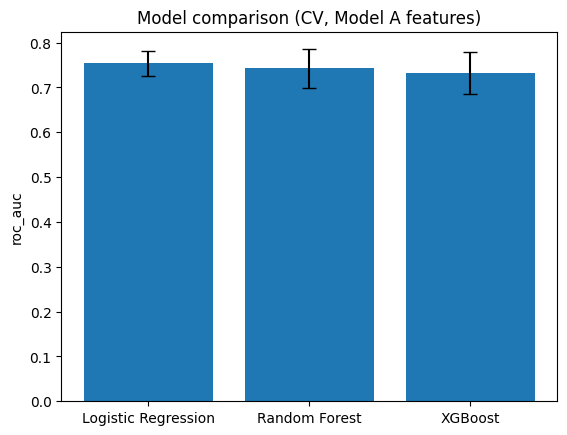

In [9]:
#SELECTING BEST MODEL

# Rank the models by the chosen metric (mean across CV folds)
means = {n: cv_raw[n][SELECTION_METRIC].mean() for n in cv_raw}
best_name = max(means, key=means.get)

print(f"MODEL SELECTION (metric: {SELECTION_METRIC})")
print("-" * 50)
for rank, (n, v) in enumerate(sorted(means.items(), key=lambda x: -x[1]), start=1):
    sd = cv_raw[n][SELECTION_METRIC].std()
    print(f"  {rank}. {n:20s} {v:.3f} ± {sd:.3f}")

# Warn if the top two models are statistically close
ranked = sorted(means.items(), key=lambda x: -x[1])
gap = ranked[0][1] - ranked[1][1]
sd_best = cv_raw[ranked[0][0]][SELECTION_METRIC].std()
if gap < sd_best:
    print(f"\nNote: gap between #1 and #2 ({gap:.3f}) is smaller than 1 SD ({sd_best:.3f}).")
    print("The models perform similarly; consider interpretability when justifying your choice.")
print(f"\n>>> Best model selected: {best_name}")

# Visual comparison with error bars (SD)
names = list(cv_raw)
plt.bar(names, [cv_raw[n][SELECTION_METRIC].mean() for n in names],
        yerr=[cv_raw[n][SELECTION_METRIC].std() for n in names], capsize=5)
plt.ylabel(SELECTION_METRIC); plt.title("Model comparison (CV, Model A features)")
plt.show()

In [11]:
def evaluate_on_test(model_name, cols, label=""):
    """Tune the threshold on training data only, then test once."""
    print(f"\n{'=' * 50}")
    print(f"EVALUATING {label} | model: {model_name} | {len(cols)} features")
    print("=" * 50)
    model = build_models()[model_name]

    # Out-of-fold probabilities on the TRAINING set -> choose the threshold
    print(f"Step 1: tuning threshold on {len(train_df)} training patients (5-fold out-of-fold)")
    oof = cross_val_predict(model, train_df[cols], y_train,
                            cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                            method="predict_proba")[:, 1]
    fpr, tpr, thr = roc_curve(y_train, oof)
    idx = np.argmax(tpr >= TARGET_RECALL)         # first point reaching target recall
    threshold = thr[idx]
    print(f"        threshold chosen = {threshold:.3f} "
          f"(training recall {tpr[idx]:.3f}, false-positive rate {fpr[idx]:.3f})")

    # Fit on all training data and predict the untouched test set
    print(f"Step 2: fitting on {len(train_df)} training patients")
    model.fit(train_df[cols], y_train)
    print(f"Step 3: predicting on {len(test_df)} test patients (first time seen)")
    proba = model.predict_proba(test_df[cols])[:, 1]
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f"        flagged as at-risk: {pred.sum()} of {len(pred)} patients")
    print(f"        caught {tp} of {tp + fn} diabetics, missed {fn}; "
          f"{fp} false alarms among {tn + fp} healthy")

    metrics = {"Threshold": round(float(threshold), 3),
               "Recall (sensitivity)": round(recall_score(y_test, pred), 3),
               "Specificity": round(tn / (tn + fp), 3),
               "Precision": round(precision_score(y_test, pred), 3),
               "F1": round(f1_score(y_test, pred), 3),
               "ROC-AUC": round(roc_auc_score(y_test, proba), 3),
               "PR-AUC": round(average_precision_score(y_test, proba), 3),
               "Brier score": round(brier_score_loss(y_test, proba), 3),
               "TP / FP / FN / TN": f"{tp} / {fp} / {fn} / {tn}"}
    return {"model": model, "proba": proba, "cols": cols, "metrics": metrics}

print("Evaluation function defined")

Evaluation function defined


In [12]:
# Same best model for both, so the only difference is the feature set
print(f"Using the selected model ({best_name}) for both feature sets")
res_A = evaluate_on_test(best_name, routine, label="MODEL A (routine only)")
res_B = evaluate_on_test(best_name, routine + lab, label="MODEL B (routine + lab)")

final_table = pd.DataFrame({f"Model A: routine ({best_name})": res_A["metrics"],
                            f"Model B: routine + lab ({best_name})": res_B["metrics"]})

gap_auc = res_B["metrics"]["ROC-AUC"] - res_A["metrics"]["ROC-AUC"]
gap_rec = res_B["metrics"]["Recall (sensitivity)"] - res_A["metrics"]["Recall (sensitivity)"]
print(f"\nValue added by lab tests: ROC-AUC +{gap_auc:.3f}, recall {gap_rec:+.3f}")
final_table

Using the selected model (Logistic Regression) for both feature sets

EVALUATING MODEL A (routine only) | model: Logistic Regression | 6 features
Step 1: tuning threshold on 614 training patients (5-fold out-of-fold)
        threshold chosen = 0.397 (training recall 0.850, false-positive rate 0.450)
Step 2: fitting on 614 training patients
Step 3: predicting on 154 test patients (first time seen)
        flagged as at-risk: 89 of 154 patients
        caught 43 of 54 diabetics, missed 11; 46 false alarms among 100 healthy

EVALUATING MODEL B (routine + lab) | model: Logistic Regression | 8 features
Step 1: tuning threshold on 614 training patients (5-fold out-of-fold)
        threshold chosen = 0.359 (training recall 0.850, false-positive rate 0.372)
Step 2: fitting on 614 training patients
Step 3: predicting on 154 test patients (first time seen)
        flagged as at-risk: 82 of 154 patients
        caught 47 of 54 diabetics, missed 7; 35 false alarms among 100 healthy

Value added by

,Model A: routine (Logistic Regression),Model B: routine + lab (Logistic Regression)
Threshold,0.397,0.359
Recall (sensitivity),0.796,0.87
Specificity,0.54,0.65
Precision,0.483,0.573
F1,0.601,0.691
ROC-AUC,0.729,0.813
PR-AUC,0.554,0.673
Brier score,0.211,0.181
TP / FP / FN / TN,43 / 46 / 11 / 54,47 / 35 / 7 / 65


Plotting ROC and calibration curves on the test set ...


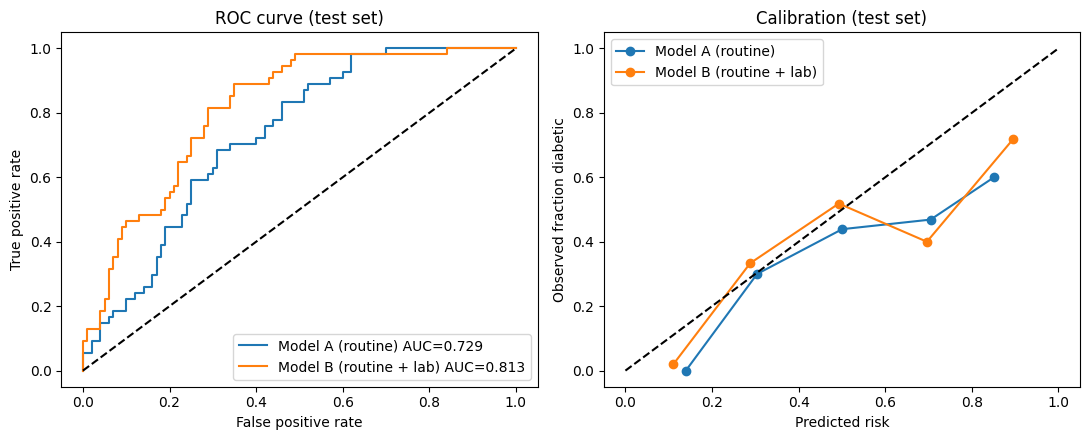

Calibration: points close to the dashed line mean the predicted risk is trustworthy


In [13]:
print("Plotting ROC and calibration curves on the test set ...")
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
for label, r in [("Model A (routine)", res_A), ("Model B (routine + lab)", res_B)]:
    fpr, tpr, _ = roc_curve(y_test, r["proba"])
    ax[0].plot(fpr, tpr, label=f"{label} AUC={r['metrics']['ROC-AUC']}")
    frac_pos, mean_pred = calibration_curve(y_test, r["proba"], n_bins=5)
    ax[1].plot(mean_pred, frac_pos, marker="o", label=label)
ax[0].plot([0, 1], [0, 1], "k--")
ax[0].set(title="ROC curve (test set)", xlabel="False positive rate", ylabel="True positive rate")
ax[1].plot([0, 1], [0, 1], "k--")
ax[1].set(title="Calibration (test set)", xlabel="Predicted risk", ylabel="Observed fraction diabetic")
ax[0].legend(); ax[1].legend(); plt.tight_layout(); plt.show()
print("Calibration: points close to the dashed line mean the predicted risk is trustworthy")

Computing permutation importance for Model A (Logistic Regression)
Shuffling each of 6 features 30 times on 154 test patients ...

Feature importance (drop in ROC-AUC when shuffled):
  BMI                          +0.0656
  Age                          +0.0312
  Pregnancies                  +0.0271
  DiabetesPedigreeFunction     +0.0136
  SkinThickness                -0.0036
  BloodPressure                -0.0043

Most influential routine measurement: BMI


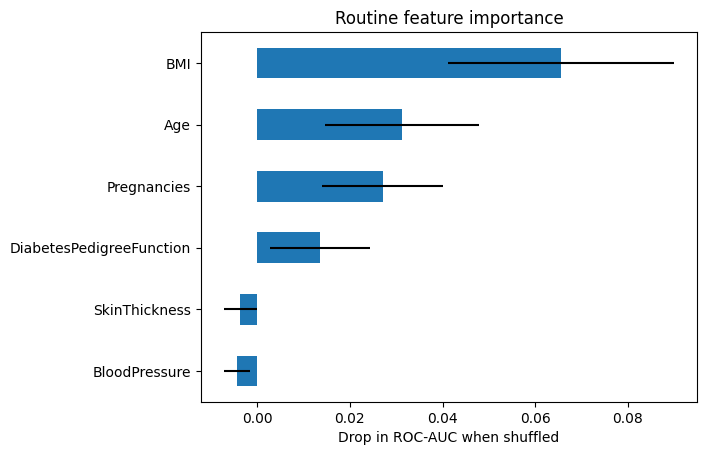

In [14]:
# Permutation importance works for ANY model type:
# it measures how much test AUC drops when a feature is shuffled.
print(f"Computing permutation importance for Model A ({best_name})")
print(f"Shuffling each of {len(routine)} features 30 times on {len(test_df)} test patients ...")

pi = permutation_importance(res_A["model"], test_df[routine], y_test,
                            scoring="roc_auc", n_repeats=30, random_state=RANDOM_STATE)
imp = pd.Series(pi.importances_mean, index=routine).sort_values(ascending=False)

print("\nFeature importance (drop in ROC-AUC when shuffled):")
for feat, val in imp.items():
    print(f"  {feat:28s} {val:+.4f}")
print(f"\nMost influential routine measurement: {imp.index[0]}")

imp.sort_values().plot.barh(xerr=pd.Series(pi.importances_std, index=routine)[imp.sort_values().index])
plt.xlabel("Drop in ROC-AUC when shuffled"); plt.title("Routine feature importance")
plt.show()